In [6]:
# This is a small model of a LIF neuron

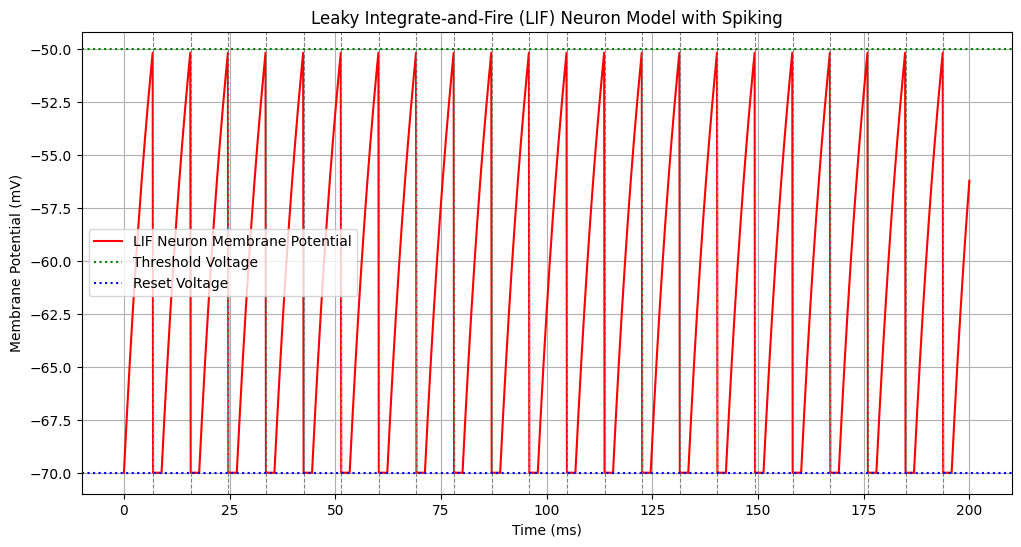

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Define the differential equation for the LIF neuron membrane potential
def dudt(u, t, k, a, R, I):
    # The equation is: a * (du/dt) = -(u - k) + R * I
    # So, du/dt = (-(u - k) + R * I) / a
    return (-(u - k) + R * I) / a

# Euler method implementation with LIF spiking logic
def euler_method_lif(dudt_func, u0, t_start, t_end, h, u_threshold, u_reset, refractory_period_steps, *args):
    t = np.arange(t_start, t_end + h, h) # Time points
    u = np.zeros(len(t)) # Array to store membrane potential values
    u[0] = u0 # Initial condition

    spike_times = []
    refractory_counter = 0

    for i in range(0, len(t) - 1):
        if refractory_counter > 0:
            # During refractory period, membrane potential remains at reset value
            u[i+1] = u_reset
            refractory_counter -= 1
        else:
            # Integrate membrane potential
            du = dudt_func(u[i], t[i], *args)
            u[i+1] = u[i] + h * du

            # Check for spike
            if u[i+1] >= u_threshold:
                spike_times.append(t[i+1])
                u[i+1] = u_reset # Reset membrane potential after spike
                refractory_counter = refractory_period_steps # Start refractory period
    return t, u, spike_times

# Parameters for the LIF Neuron Model
k = -60.0    # Membrane resting potential (mV)
y0 = -70.0   # Initial membrane potential (mV)
t_start = 0.0  # Start time (ms)
t_end = 200.0  # End time (ms)
h_val = 0.1    # Step size for Euler method (ms)
a = 10.0     # Membrane time constant (ms)
R = 10.0     # Membrane resistance (MOhms)
I = 3.0      # Injected current (nA) - Increased for spiking

u_threshold = -50.0 # Spike threshold (mV)
u_reset = -70.0   # Reset potential after spike (mV)
refractory_period = 2.0 # Refractory period (ms)
refractory_period_steps = int(refractory_period / h_val)

# Solve using Euler method with LIF spiking logic
t_euler, u_euler, spike_times = euler_method_lif(
    dudt, y0, t_start, t_end, h_val, u_threshold, u_reset, refractory_period_steps, k, a, R, I
)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(t_euler, u_euler, 'r-', label='LIF Neuron Membrane Potential')

# Plot spikes as vertical lines
for spike_time in spike_times:
    plt.axvline(spike_time, color='gray', linestyle='--', linewidth=0.8)

# Plot threshold and reset lines
plt.axhline(u_threshold, color='green', linestyle=':', label='Threshold Voltage')
plt.axhline(u_reset, color='blue', linestyle=':', label='Reset Voltage')

plt.title('Leaky Integrate-and-Fire (LIF) Neuron Model with Spiking')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.grid(True)
plt.show()

This is an example of a LIF neuron model, based upon the concept of the neuronal membrane being modeled as a circuit with two paths for current flow across the potential difference of the cell membrane.

one path (Path 1) is through a capacitor C, exemplifying the lipid bilayer chemistry of the neuron membrane. Another path (Path 2) is through a resistance and a battery in series, representing the effect of ion channels and pumps in the cell membrane.

Another condition is also the firing time condition, which signifies the neuron's primary role to 'fire' a spike just as the potential crosses a certain limit, after which the membrane returns to resting potential.

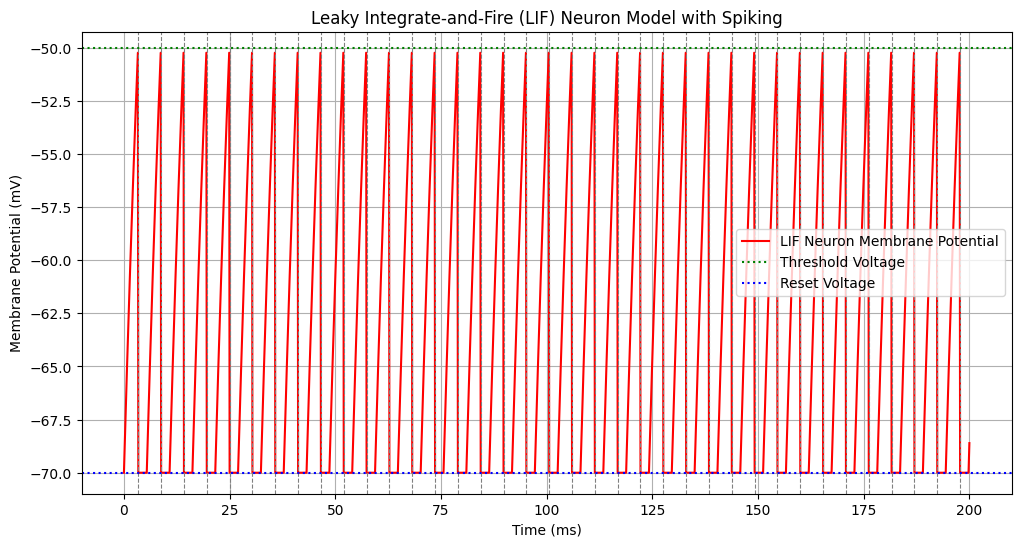

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Define the differential equation for the LIF neuron membrane potential
def dudt(u, t, k, a, R, I):
    # The equation is: a * (du/dt) = -(u - k) + R * I
    # So, du/dt = (-(u - k) + R * I) / a
    return (-(u - k) + R * I) / a

# Euler method implementation with LIF spiking logic
def euler_method_lif(dudt_func, u0, t_start, t_end, h, u_threshold, u_reset, refractory_period_steps, *args):
    t = np.arange(t_start, t_end + h, h) # Time points
    u = np.zeros(len(t)) # Array to store membrane potential values
    u[0] = u0 # Initial condition

    spike_times = []
    refractory_counter = 0

    for i in range(0, len(t) - 1):
        if refractory_counter > 0:
            # During refractory period, membrane potential remains at reset value
            u[i+1] = u_reset
            refractory_counter -= 1
        else:
            # Integrate membrane potential
            du = dudt_func(u[i], t[i], *args)
            u[i+1] = u[i] + h * du

            # Check for spike
            if u[i+1] >= u_threshold:
                spike_times.append(t[i+1])
                u[i+1] = u_reset # Reset membrane potential after spike
                refractory_counter = refractory_period_steps # Start refractory period
    return t, u, spike_times

# Parameters for the LIF Neuron Model
k = -60.0    # Membrane resting potential (mV)
y0 = -70.0   # Initial membrane potential (mV)
t_start = 0.0  # Start time (ms)
t_end = 200.0  # End time (ms)
h_val = 0.1    # Step size for Euler method (ms)
a = 10.0     # Membrane time constant (ms)
R = 30.0     # Membrane resistance (MOhms)
I = 2.0      # Injected current (nA) - Increased for spiking

u_threshold = -50.0 # Spike threshold (mV)
u_reset = -70.0   # Reset potential after spike (mV)
refractory_period = 2.0 # Refractory period (ms)
refractory_period_steps = int(refractory_period / h_val)

# Solve using Euler method with LIF spiking logic
t_euler, u_euler, spike_times = euler_method_lif(
    dudt, y0, t_start, t_end, h_val, u_threshold, u_reset, refractory_period_steps, k, a, R, I
)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(t_euler, u_euler, 'r-', label='LIF Neuron Membrane Potential')

# Plot spikes as vertical lines
for spike_time in spike_times:
    plt.axvline(spike_time, color='gray', linestyle='--', linewidth=0.8)

# Plot threshold and reset lines
plt.axhline(u_threshold, color='green', linestyle=':', label='Threshold Voltage')
plt.axhline(u_reset, color='blue', linestyle=':', label='Reset Voltage')

plt.title('Leaky Integrate-and-Fire (LIF) Neuron Model with Spiking')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.grid(True)
plt.show()

This is the same model with a different Resistance of 100 mOhms, from the previous 10 mOhms. The change, exemplified by the increased number of peaks and decreased interpeak interval, implies a decrease in current flow through the membrane through path 2.